In [1]:
# Dataseti indirin (URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions)
!kaggle datasets download -d tboyle10/medicaltranscriptions

# Zip dosyasını açın
!unzip medicaltranscriptions.zip

Dataset URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions
License(s): CC0-1.0
100% 4.85M/4.85M [00:00<00:00, 38.6MB/s]
100% 4.85M/4.85M [00:00<00:00, 38.4MB/s]
Archive:  medicaltranscriptions.zip
  inflating: mtsamples.csv           


In [2]:
!ls  # mtsamples.csv dosyasını göreceksiniz

medicaltranscriptions.zip  mtsamples.csv  sample_data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import string
import re
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [4]:
clinical_text_df = pd.read_csv('mtsamples.csv')

In [5]:
clinical_text_df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [6]:
clinical_text_df = clinical_text_df[clinical_text_df["transcription"].notna()]

In [7]:
data_categories = clinical_text_df.groupby(clinical_text_df['medical_specialty'])

In [8]:
c=1
for cat_name,data_category in data_categories:
  print(f"Category_{c}: {cat_name}: {len(data_category)}")
  c+=1

Category_1:  Allergy / Immunology: 7
Category_2:  Autopsy: 8
Category_3:  Bariatrics: 18
Category_4:  Cardiovascular / Pulmonary: 371
Category_5:  Chiropractic: 14
Category_6:  Consult - History and Phy.: 516
Category_7:  Cosmetic / Plastic Surgery: 27
Category_8:  Dentistry: 27
Category_9:  Dermatology: 29
Category_10:  Diets and Nutritions: 10
Category_11:  Discharge Summary: 108
Category_12:  ENT - Otolaryngology: 96
Category_13:  Emergency Room Reports: 75
Category_14:  Endocrinology: 19
Category_15:  Gastroenterology: 224
Category_16:  General Medicine: 259
Category_17:  Hematology - Oncology: 90
Category_18:  Hospice - Palliative Care: 6
Category_19:  IME-QME-Work Comp etc.: 16
Category_20:  Lab Medicine - Pathology: 8
Category_21:  Letters: 23
Category_22:  Nephrology: 81
Category_23:  Neurology: 223
Category_24:  Neurosurgery: 94
Category_25:  Obstetrics / Gynecology: 155
Category_26:  Office Notes: 50
Category_27:  Ophthalmology: 83
Category_28:  Orthopedic: 355
Category_29:  

In [9]:
filtered_data_categories = data_categories.filter(lambda x: x.shape[0]>50)
final_data_categories = filtered_data_categories.groupby(filtered_data_categories['medical_specialty'])

In [10]:
c=1
for cat_name,data_category in final_data_categories:
  print(f"Category_{c}: {cat_name}: {len(data_category)}")
  c+=1

Category_1:  Cardiovascular / Pulmonary: 371
Category_2:  Consult - History and Phy.: 516
Category_3:  Discharge Summary: 108
Category_4:  ENT - Otolaryngology: 96
Category_5:  Emergency Room Reports: 75
Category_6:  Gastroenterology: 224
Category_7:  General Medicine: 259
Category_8:  Hematology - Oncology: 90
Category_9:  Nephrology: 81
Category_10:  Neurology: 223
Category_11:  Neurosurgery: 94
Category_12:  Obstetrics / Gynecology: 155
Category_13:  Ophthalmology: 83
Category_14:  Orthopedic: 355
Category_15:  Pain Management: 61
Category_16:  Pediatrics - Neonatal: 70
Category_17:  Psychiatry / Psychology: 53
Category_18:  Radiology: 273
Category_19:  SOAP / Chart / Progress Notes: 166
Category_20:  Surgery: 1088
Category_21:  Urology: 156


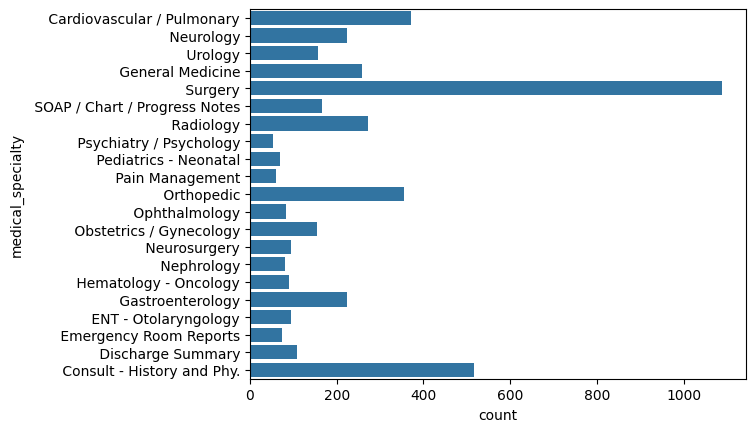

In [11]:
plt.figure()
sns.countplot(y="medical_specialty",data=filtered_data_categories)
plt.show()

In [13]:
data = filtered_data_categories[["transcription", "medical_specialty"]]
data = data.drop(data[data["transcription"].isna()].index)
data

,transcription,medical_specialty
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",Cardiovascular / Pulmonary
4,1. The left ventricular cavity size and wall ...,Cardiovascular / Pulmonary
7,"2-D ECHOCARDIOGRAM,Multiple views of the heart...",Cardiovascular / Pulmonary
9,"DESCRIPTION:,1. Normal cardiac chambers size....",Cardiovascular / Pulmonary
11,"2-D STUDY,1. Mild aortic stenosis, widely calc...",Cardiovascular / Pulmonary
...,...,...
4972,"INDICATION: , Chest pain.,TYPE OF TEST: , Aden...",Cardiovascular / Pulmonary
4973,"CHIEF COMPLAINT: , Chest pain.,HISTORY OF PRES...",Cardiovascular / Pulmonary
4974,"HISTORY OF PRESENT ILLNESS: , The patient is a...",Cardiovascular / Pulmonary
4975,"HISTORY OF PRESENT ILLNESS: , Mr. ABC is a 60-...",Cardiovascular / Pulmonary


In [14]:
def clean_text(text):
    text = text.translate(str.maketrans('', '', string.punctuation)) # norktalama işaterlerini kaldırıyor

    text1 = "".join([w for w in text if not w.isdigit()])

    replate_by_space_re = re.compile('[/(){}\[\]\|@,;]')

    text2 = text.lower()
    text2 = replate_by_space_re.sub("",text2)

    return text2

In [15]:
def lemmatize_text(text):
    wordlist = []
    lemmatizer = WordNetLemmatizer()

    sentences = sent_tokenize(text)

    initial_sentence = sentences[0:1]
    final_sentence = sentences[len(sentences)-2:len(sentences)-1]

    for sentence in initial_sentence:
      words = word_tokenize(sentence)
      for word in words:
        wordlist.append(lemmatizer.lemmatize(word))

    for sentence in final_sentence:
      words = word_tokenize(sentence)
      for word in words:
        wordlist.append(lemmatizer.lemmatize(word))

    return " ".join(wordlist)

In [20]:
import nltk

nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [21]:
data["transcription"] = data["transcription"].apply(lemmatize_text)
data["transcription"] = data["transcription"].apply(clean_text)

In [22]:
data

,transcription,medical_specialty
3,2d mmode 1 left atrial enlargement with left a...,Cardiovascular / Pulmonary
4,1 the left ventricular cavity size and wall th...,Cardiovascular / Pulmonary
7,2d echocardiogrammultiple view of the heart an...,Cardiovascular / Pulmonary
9,description1 normal cardiac chamber size2 norm...,Cardiovascular / Pulmonary
11,2d study1 mild aortic stenosis widely calcifie...,Cardiovascular / Pulmonary
...,...,...
4972,indication chest paintype of test adenosine wi...,Cardiovascular / Pulmonary
4973,chief complaint chest painhistory of present i...,Cardiovascular / Pulmonary
4974,history of present illness the patient is a 68...,Cardiovascular / Pulmonary
4975,history of present illness mr abc is a 60yearo...,Cardiovascular / Pulmonary


In [23]:
# metin temsili: metinleri sayısal olarak ifade edilmesi
vectorizer = TfidfVectorizer(stop_words="english",max_features=1000)
tfidf = vectorizer.fit_transform(data["transcription"].tolist())
feature_names = sorted(vectorizer.get_feature_names_out())

labels = data["medical_specialty"].tolist()
tsne = TSNE(n_components=2,)
tsne_results = tsne.fit_transform(tfidf.toarray())

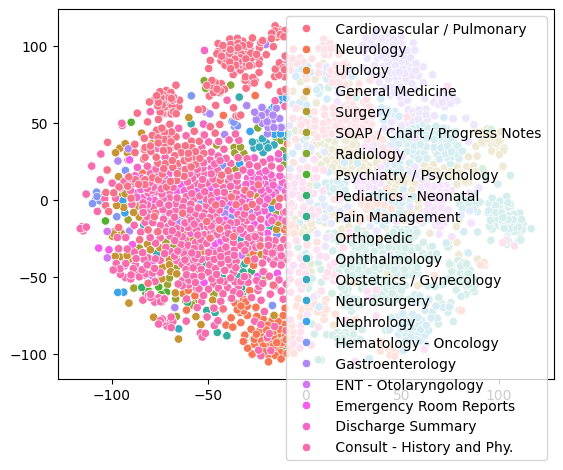

In [24]:
sns.scatterplot(x=tsne_results[:,0],y=tsne_results[:,1],hue=labels)
plt.show()

In [27]:
pca = PCA()
tfidf_reduced = pca.fit_transform(tfidf.toarray())
labels = data["medical_specialty"].tolist()
category_list = data.medical_specialty.unique()

X_train,X_test,y_train,y_test=train_test_split(tfidf_reduced,labels,random_state=42)

lr = LogisticRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)



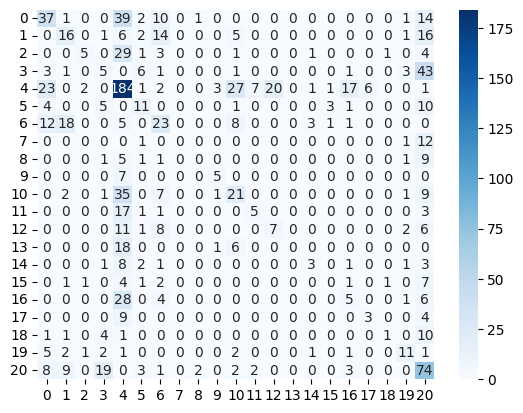

In [28]:
cm = confusion_matrix(y_test,y_pred,labels = category_list)
sns.heatmap(cm,annot=True,cmap="Blues",fmt="g")
plt.show()